In [ ]:
%pip install mediapipe opencv-python scikit-learn torch pandas

In [1]:
import mediapipe as mp
import cv2
import numpy as np
import uuid
import os
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
mp_drawing = mp.solutions.drawing_utils
mp_hands = mp.solutions.hands

In [3]:
class Model(nn.Module):
    def __init__(self, in_features=180, h1=64, h2=32, out_features=3):
        super(Model, self).__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

In [4]:
path = '../data.csv'
df = pd.read_csv(path, header=None, names=['type', 'name', 'x1', 'y1', 'z1', 'x2', 'y2', 'z2', 'x3', 'y3', 'z3', 'x4', 'y4', 'z4'])
df = df.drop('name', axis=1)
df

n = 15  # rows per sequence
num_groups = df.shape[0] // n

def make_relative_per_landmark(group):
    for i in range(1, 5):
        x_col, y_col, z_col = f'x{i}', f'y{i}', f'z{i}'
        x0, y0, z0 = group.iloc[0][[x_col, y_col, z_col]]
        group[x_col] = group[x_col] - x0
        group[y_col] = group[y_col] - y0
        group[z_col] = group[z_col] - z0
    coords_array = group[[f'x{i}' for i in range(1, 5)] + [f'y{i}' for i in range(1, 5)] + [f'z{i}' for i in range(1,5)]].to_numpy()
    coords_reshaped = coords_array.reshape(len(group), 4, 3)
    
    distances = np.linalg.norm(coords_reshaped, axis=2)
    max_distance = distances.max()
    coords_normalized = coords_reshaped / max_distance if max_distance > 0 else coords_reshaped

    group[[f'x{i}' for i in range(1, 5)] + [f'y{i}' for i in range(1, 5)] + [f'z{i}' for i in range(1,5)]] = coords_normalized.reshape(len(group), 12)
    
    return group

groups = [make_relative_per_landmark(df.iloc[i*n:(i+1)*n].copy()) for i in range(num_groups)]
df_rel = pd.concat(groups, ignore_index=True)

df = df_rel

df

,type,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,y4,z4
0,uppercut_left,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,uppercut_left,0.001174,0.066383,0.395484,0.003410,0.004650,0.329600,-0.000150,0.002610,0.140113,-0.000234,0.000132,0.238581
2,uppercut_left,0.001794,0.192430,0.190312,0.006705,0.010519,0.375934,-0.007076,0.013041,0.006939,-0.001998,0.002426,0.301547
3,uppercut_left,0.038695,0.253163,0.087585,0.014573,0.019896,0.454424,-0.014408,0.027310,-0.118500,-0.002757,0.006865,0.357960
4,uppercut_left,0.067540,0.299136,0.030312,0.021467,0.027640,0.499319,-0.014297,0.035188,-0.169566,-0.002758,0.015437,0.380980
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1750,uppercut_right,-0.028178,0.211339,0.026915,-0.046177,-0.057787,-0.242509,-0.026320,0.025786,0.064813,-0.063064,-0.174635,-0.098501
1751,uppercut_right,0.033329,-0.309145,0.823086,-0.111116,-0.391969,0.410516,-0.018957,-0.274407,0.423359,-0.154959,-0.497223,0.119591
1752,uppercut_right,0.020576,0.192754,0.321344,-0.095748,-0.295791,0.091267,0.010096,-0.224151,0.215790,-0.105983,-0.374959,-0.016217
1753,uppercut_right,0.014370,0.210583,-0.173866,0.051727,0.122301,-0.328047,0.007290,-0.175994,-0.029318,-0.002796,-0.100053,-0.039669


In [5]:
df['type'] = df['type'].replace('hook_left', 'hook')
df['type'] = df['type'].replace('hook_right', 'hook')
df['type'] = df['type'].replace('jab_left', 'jab')
df['type'] = df['type'].replace('jab_right', 'jab')
df['type'] = df['type'].replace('uppercut_left', 'uppercut')
df['type'] = df['type'].replace('uppercut_right', 'uppercut')
type_mapping = {'hook': 0, 'jab': 1, 'uppercut': 2}
df['type'] = df['type'].map(type_mapping)

X = np.array(df.drop('type', axis=1))
y = np.array(df['type'])

In [6]:
features = ['x1', 'y1', 'z1', 'x2', 'y2', 'z2', 'x3', 'y3', 'z3', 'x4', 'y4', 'z4']

n = 15
num_groups = df.shape[0] // n

# Trim the DataFrame to a multiple of n
df_trim = df.iloc[:num_groups * n]

# Convert to NumPy array (only features)
arr = df_trim[features].values  # shape: (num_groups * n, 12)

# Reshape into sequences of 15 rows
grouped = arr.reshape(num_groups, n, len(features))  # shape: (num_groups, 15, 12)

# Flatten each sequence into a single vector
X = grouped.reshape(num_groups, -1)  # shape: (num_groups, 15*12=180)

# Handle labels (assume df['type'] is the label)
y_arr = df_trim['type'].values
y = y_arr.reshape(num_groups, n)[:, 0]  # take first row's label for each sequence

print("X shape:", X.shape)  # should be (num_groups, 180)
print("y shape:", y.shape)  # should be (num_groups,)

X shape: (117, 180)
y shape: (117,)


In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
X = scaler.fit_transform(X)

In [14]:
torch.manual_seed(42)
model = Model()
model

Model(
  (fc1): Linear(in_features=180, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (out): Linear(in_features=32, out_features=3, bias=True)
)

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# convert X features to float tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

# convert y labels to long tensors (64-bit integers)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [17]:
# set criterion of model to measure error (how far off predictions are from data)
criterion = nn.CrossEntropyLoss()

# choose Adam Optimizer
# lr = learning rate (if error doesn't go down after a bunch of epochs, must lower our learning rate)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [18]:
# train our model
# epoch = one run through all training data in our network
epochs = 120
train_losses = []
test_losses = []

for i in range(epochs):
  # Training phase
  model.train()
  y_pred = model.forward(X_train) # get predicted results
  train_loss = criterion(y_pred, y_train) # predicted vs training y
  
  # back propagation
  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()
  
  # Evaluation phase (no gradients needed)
  model.eval()
  with torch.no_grad():
    y_test_pred = model.forward(X_test)
    test_loss = criterion(y_test_pred, y_test)
  
  # keep track of losses
  train_losses.append(train_loss.detach().numpy())
  test_losses.append(test_loss.detach().numpy())
  
  if i % 10 == 0:
    print(f'Epoch: {i} | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}')

Epoch: 0 | Train Loss: 1.107195 | Test Loss: 1.225617
Epoch: 10 | Train Loss: 1.054687 | Test Loss: 1.106874
Epoch: 20 | Train Loss: 0.953906 | Test Loss: 1.084939
Epoch: 30 | Train Loss: 0.866671 | Test Loss: 1.228127
Epoch: 40 | Train Loss: 0.778432 | Test Loss: 1.325554
Epoch: 50 | Train Loss: 0.702967 | Test Loss: 1.450971
Epoch: 60 | Train Loss: 0.648297 | Test Loss: 1.524288
Epoch: 70 | Train Loss: 0.576787 | Test Loss: 1.610330
Epoch: 80 | Train Loss: 0.493044 | Test Loss: 1.606099
Epoch: 90 | Train Loss: 0.429922 | Test Loss: 1.688891
Epoch: 100 | Train Loss: 0.373013 | Test Loss: 1.940476
Epoch: 110 | Train Loss: 0.320081 | Test Loss: 2.031612


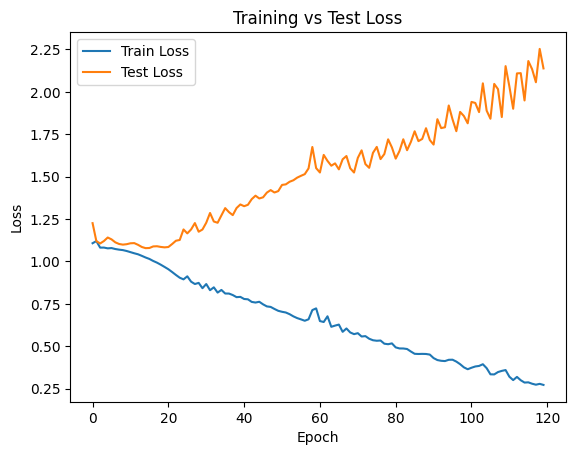

In [19]:
# plot the losses
plt.plot(range(epochs), train_losses, label='Train Loss')
plt.plot(range(epochs), test_losses, label='Test Loss')
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.title("Training vs Test Loss")
plt.show()

In [20]:
# evaluate model on test data
with torch.no_grad():
  y_eval = model.forward(X_test)
  loss = criterion(y_eval, y_test)

loss

tensor(2.1381)

In [21]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    if y_test[i] == 0:
      x = "hook"
    elif y_test[i] == 1:
      x = "uppercut"
    elif y_test[i] == 2:
      x = "jab"

    print(f'{i+1}.) {str(y_val)} \t {y_test[i]} \t {y_val.argmax().item()}')

    if y_val.argmax().item() == y_test[i]:
      correct += 1

print(f'We got {correct} out of {len(X_test)} correct.')

1.) tensor([ 0.8110, -1.2165,  0.4641]) 	 0 	 0
2.) tensor([-0.2860, -0.7436,  1.1345]) 	 2 	 2
3.) tensor([ 2.6807,  1.5212, -3.7090]) 	 0 	 0
4.) tensor([ 4.5854,  1.4890, -7.5415]) 	 0 	 0
5.) tensor([ 0.4798,  1.7371, -2.7499]) 	 2 	 1
6.) tensor([ 1.5922, -0.5717, -1.5286]) 	 1 	 0
7.) tensor([ 0.1852,  2.6624, -2.4126]) 	 1 	 1
8.) tensor([ 4.1476, -4.4459, -1.0625]) 	 1 	 0
9.) tensor([ 3.0184,  2.4002, -5.9106]) 	 0 	 0
10.) tensor([-0.8548,  2.6463, -1.4131]) 	 2 	 1
11.) tensor([ 1.6678, -0.0729, -1.3355]) 	 0 	 0
12.) tensor([  7.3843,   3.6659, -12.4242]) 	 0 	 0
13.) tensor([ 0.3396,  3.0702, -2.9564]) 	 1 	 1
14.) tensor([ 0.3267, -2.7230,  1.8041]) 	 2 	 2
15.) tensor([ 0.4088,  2.3821, -3.0347]) 	 0 	 1
16.) tensor([-0.7452, -2.5421,  3.2964]) 	 2 	 2
17.) tensor([ 0.7755, -0.5116, -0.0626]) 	 1 	 0
18.) tensor([ 2.7458, -0.3701, -2.5956]) 	 2 	 0
19.) tensor([ 3.5518,  3.4944, -6.9328]) 	 1 	 0
20.) tensor([-0.6071,  3.5487, -2.5046]) 	 1 	 1
21.) tensor([ 0.4782, -1.3

In [111]:
torch.save(model.state_dict(), "model_state.pt")